# Abhishek kothari
# Homework 3B

### Question 1

In [14]:
## A)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.datasets import fetch_openml
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.datasets import fetch_20newsgroups
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

In [5]:
print("Loading MNIST dataset...")
mnist = tf.keras.datasets.mnist.load_data()
(X_train, y_train), (X_test, y_test) = mnist

# Flatten the images (28x28 → 784)
X_train = X_train.reshape(-1, 784).astype(np.float32) / 255.0  # Normalize
y_train = np.array(y_train)

Loading MNIST dataset...


In [8]:
def run_tsne(X, y, title, perplexity=30, dimensions=2):
    tsne = TSNE(n_components=dimensions, perplexity=perplexity, random_state=42)
    X_tsne = tsne.fit_transform(X)
    
    # Plot results
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="tab10", alpha=0.6)
    plt.colorbar(scatter)
    plt.title(f"{title} - Perplexity {perplexity}")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.show()

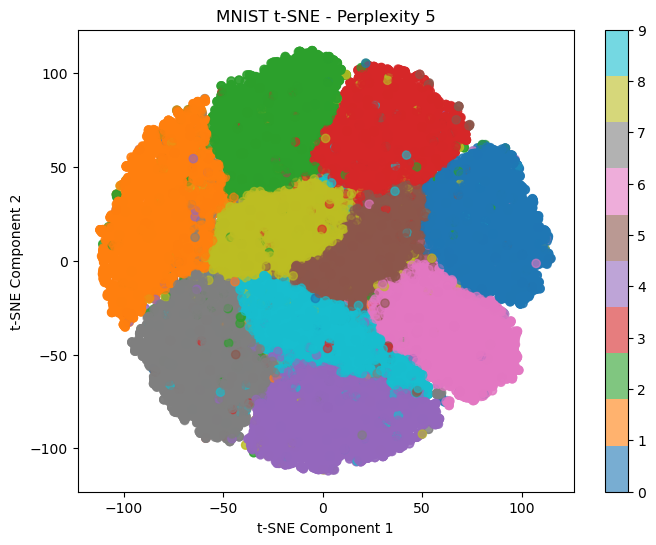

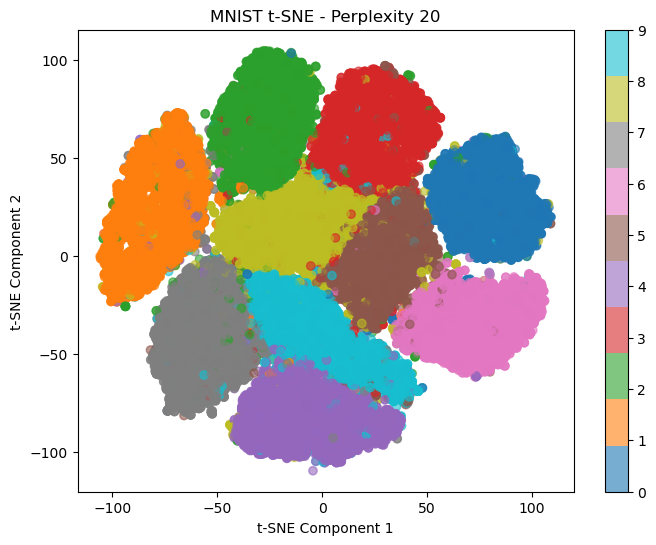

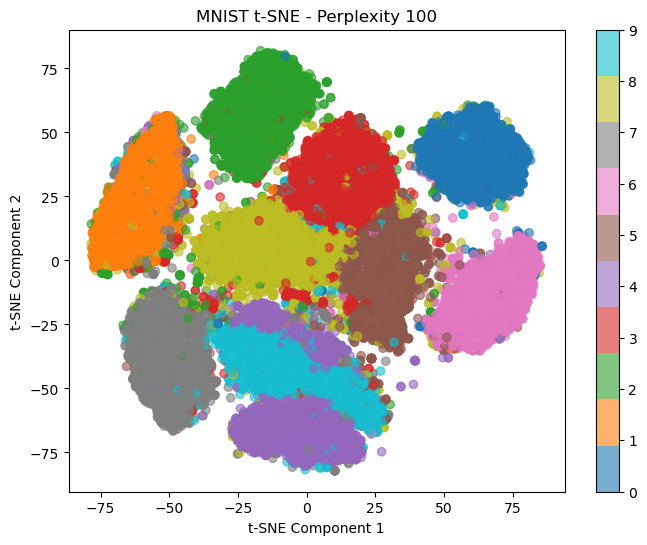

In [12]:
for perplexity in [5, 20, 100]:
    run_tsne(X_train, y_train, "MNIST t-SNE", perplexity=perplexity)

In [25]:
print("Loading 20 Newsgroups dataset...")
newsgroups = fetch_20newsgroups(subset="train", remove=('headers', 'footers', 'quotes'))
X_texts = newsgroups.data
y_texts = newsgroups.target

vectorizer = TfidfVectorizer(max_features=1000)  # Limit features for efficiency
X_texts = vectorizer.fit_transform(X_texts).toarray()

# Normalize the features
X_texts = StandardScaler().fit_transform(X_texts)

Loading 20 Newsgroups dataset...


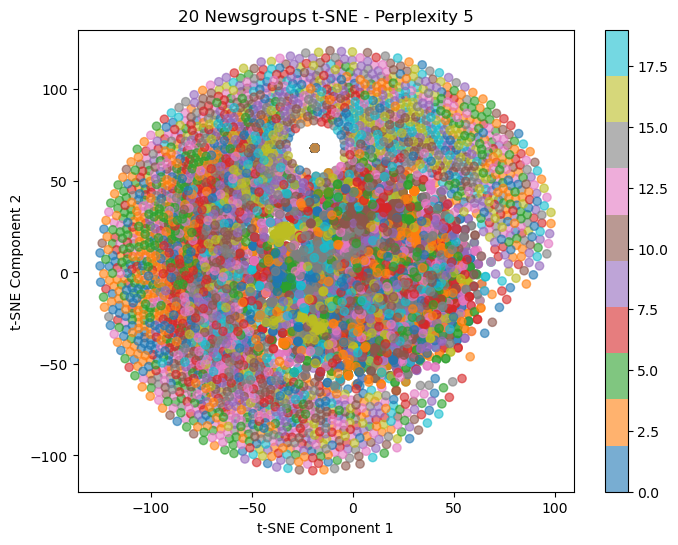

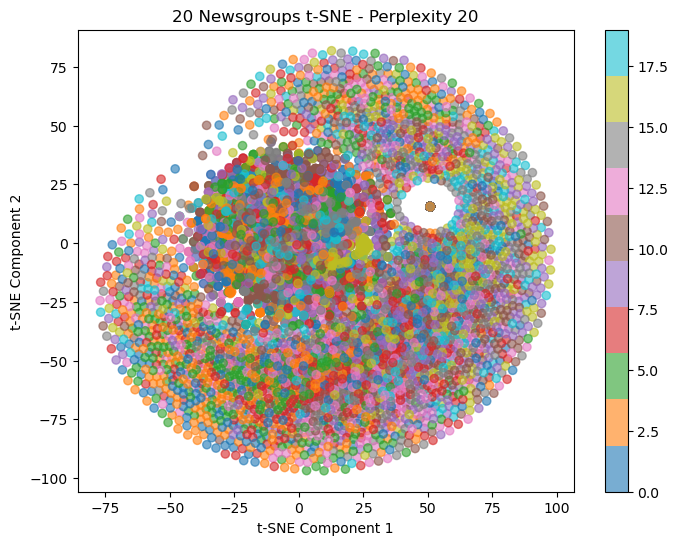

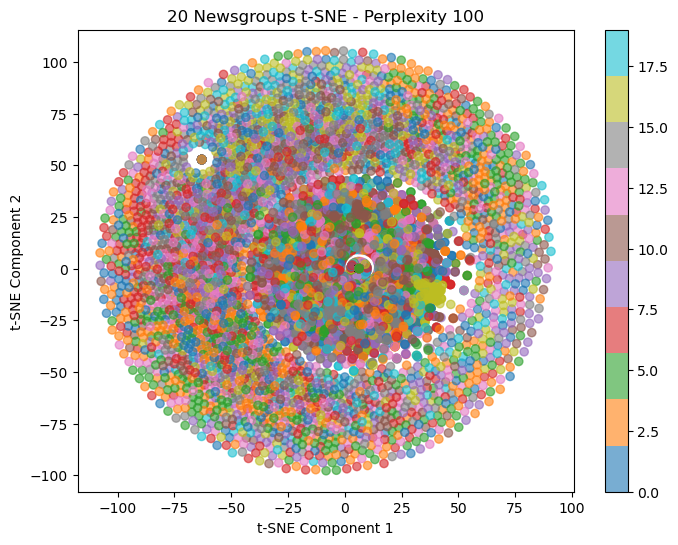

In [27]:
for perplexity in [5, 20, 100]:
    run_tsne(X_texts, y_texts, "20 Newsgroups t-SNE", perplexity=perplexity)

In [33]:
### B)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.metrics import confusion_matrix
from tensorflow.keras.datasets import mnist



In [35]:
# Load dataset
(X_train, y_train), (_, _) = mnist.load_data()

# Flatten images to vectors and normalize
X_train = X_train.reshape(X_train.shape[0], -1) / 255.0

# Step 1: Apply PCA (60 dimensions)
pca = PCA(n_components=60, random_state=42)
X_pca = pca.fit_transform(X_train)


In [82]:
# Function to apply t-SNE and DBSCAN
def apply_tsne_dbscan(X_pca, components):
    print(f"Running t-SNE with {components} dimensions...")
    tsne = TSNE(n_components=components, perplexity=40, n_iter=1000, random_state=42)
    X_tsne = tsne.fit_transform(X_pca)

    # Apply DBSCAN
    print(f"Running DBSCAN on {components}D t-SNE results...")
    dbscan = DBSCAN(eps=3, min_samples=45)
    cluster_labels = dbscan.fit_predict(X_tsne)

    return X_tsne, cluster_labels

In [84]:
# Apply t-SNE + DBSCAN for 2D, 3D, 5D
X_tsne_2D, labels_2D = apply_tsne_dbscan(X_pca, 2)
X_tsne_3D, labels_3D = apply_tsne_dbscan(X_pca, 3)
#X_tsne_5D, labels_5D = apply_tsne_dbscan(X_pca, 5)

Running t-SNE with 2 dimensions...


/Users/DELL/anaconda3/anaconda3/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Running DBSCAN on 2D t-SNE results...
Running t-SNE with 3 dimensions...


/Users/DELL/anaconda3/anaconda3/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Running DBSCAN on 3D t-SNE results...


In [86]:
import numpy as np

np.savez("tsne_dbscan_results.npz",
         X_tsne_2D=X_tsne_2D, labels_2D=labels_2D,
         X_tsne_3D=X_tsne_3D, labels_3D=labels_3D)

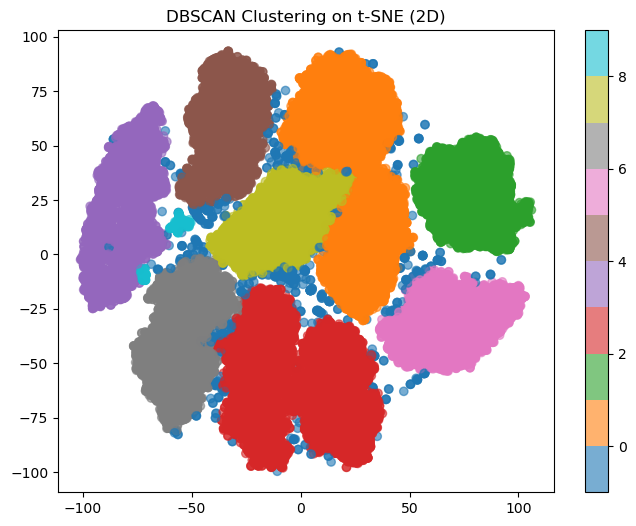

In [88]:
# Step 2: Visualize t-SNE 2D with DBSCAN clustering
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne_2D[:, 0], X_tsne_2D[:, 1], c=labels_2D, cmap='tab10', alpha=0.6)
plt.colorbar(scatter)
plt.title("DBSCAN Clustering on t-SNE (2D)")
plt.show()

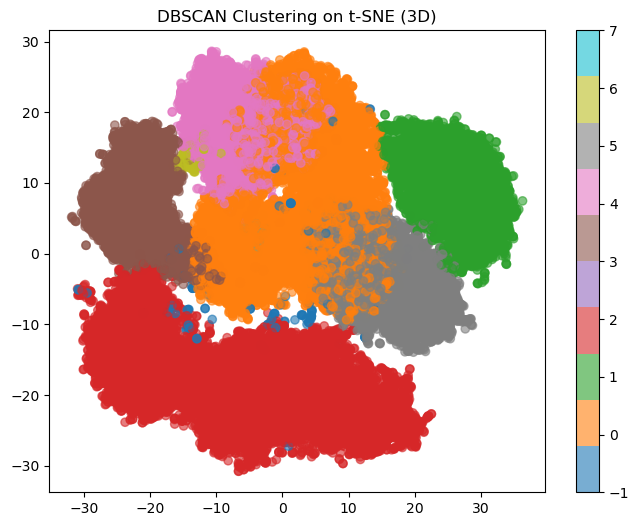

In [96]:
# Step 2: Visualize t-SNE 2D with DBSCAN clustering
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne_3D[:, 0], X_tsne_3D[:, 1], c=labels_3D, cmap='tab10', alpha=0.6)
plt.colorbar(scatter)
plt.title("DBSCAN Clustering on t-SNE (3D)")
plt.show()

In [90]:
# Step 3: Compute and plot confusion matrix
def plot_confusion_matrix(true_labels, cluster_labels):
    valid_indices = cluster_labels != -1  # Ignore noise points
    cm = confusion_matrix(true_labels[valid_indices], cluster_labels[valid_indices])

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Cluster ID")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix for DBSCAN Clustering")
    plt.show()

In [92]:
# Adjust DBSCAN parameters
dbscan = DBSCAN(eps=3, min_samples=45)  # Try different eps and min_samples
cluster_labels = dbscan.fit_predict(X_tsne_2D)

print("Unique clusters:", np.unique(cluster_labels))

Unique clusters: [-1  0  1  2  3  4  5  6  7  8  9]


In [130]:
# Adjust DBSCAN parameters
dbscan = DBSCAN(eps=2.35, min_samples=50)  # Try different eps and min_samples
cluster_labels_3D = dbscan.fit_predict(X_tsne_3D)

print("Unique clusters:", np.unique(cluster_labels_3D))

Unique clusters: [-1  0  1  2  3  4  5  6  7  8  9]


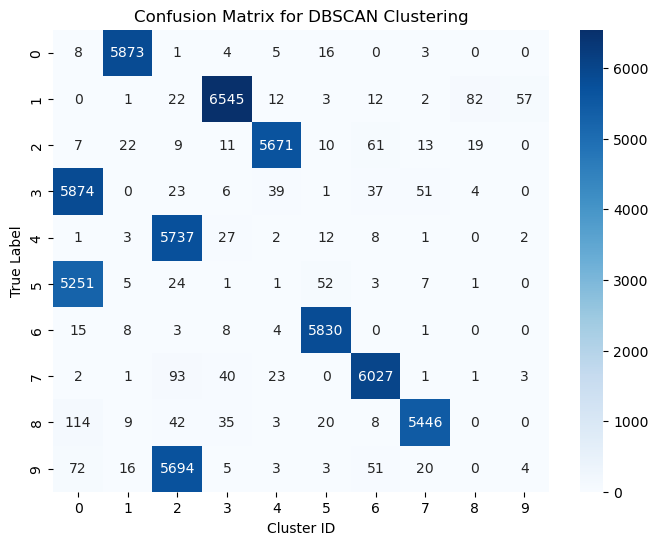

In [94]:
# Plot confusion matrix for 2D t-SNE + DBSCAN
plot_confusion_matrix(y_train, cluster_labels)

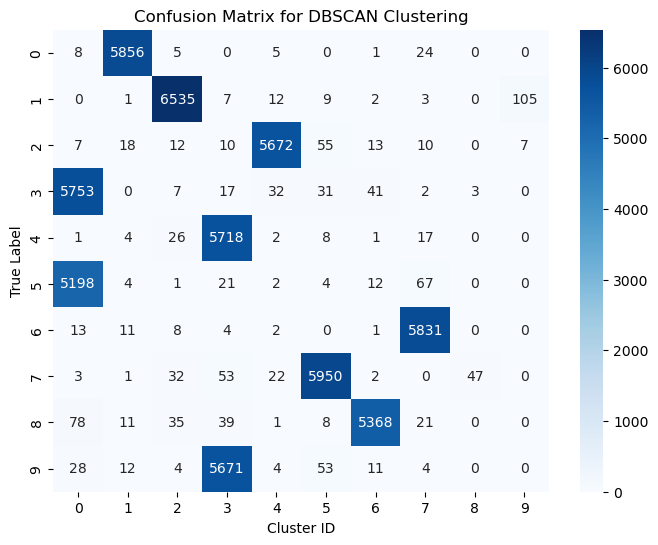

In [132]:
# Plot confusion matrix for 2D t-SNE + DBSCAN
plot_confusion_matrix(y_train, cluster_labels_3D)

### Question 2

In [135]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform
from scipy.special import xlogy

In [139]:
def compute_pairwise_distances(X):
    """Computes the pairwise Euclidean distance matrix D"""
    return squareform(pdist(X, 'euclidean')) ** 2

def compute_p_ij(D, target_perplexity=30.0, tol=1e-5):
    """
    Compute similarity matrix P using binary search for β.
    """
    N = D.shape[0]
    P = np.zeros((N, N))
    betas = np.ones(N) * 0.6  # Initialize beta values
    
    logU = np.log2(target_perplexity)  # Target entropy

    for i in range(N):
        betamin, betamax = -np.inf, np.inf
        Di = np.delete(D[i, :], i)  # Remove diagonal
        P_i = np.exp(-Di * betas[i])
        P_i /= np.sum(P_i)
        
        for _ in range(50):  # Max trials
            H = -np.sum(P_i * np.log2(P_i))  # Shannon entropy
            Hdiff = H - logU  # Difference from target entropy
            
            if np.abs(Hdiff) < tol:
                break

            if Hdiff > 0:  # Increase beta
                betamin = betas[i]
                betas[i] = (betas[i] * 2) if betamax == np.inf else (betas[i] + betamax) / 2
            else:  # Decrease beta
                betamax = betas[i]
                betas[i] = (betas[i] / 2) if betamin == -np.inf else (betas[i] + betamin) / 2

            P_i = np.exp(-Di * betas[i])
            P_i /= np.sum(P_i)

        P[i, np.arange(N) != i] = P_i  # Assign P_i to row i

    P = (P + P.T) / 2  # Symmetric P
    P /= np.sum(P)  # Normalize P
    return P

def run_tsne(X, y, no_dims=2, max_iter=400, epsilon=500, min_gain=0.01, use_momentum=True):
    """
    Run t-SNE algorithm on input data.
    """
    N = X.shape[0]
    
    # PCA to reduce dimensions to 50
    X_pca = PCA(n_components=50).fit_transform(X)
    
    # Compute pairwise distances and P-matrix
    D = compute_pairwise_distances(X_pca)
    P = compute_p_ij(D)
    const_KL = np.sum(xlogy(P, P))

    # Initialize variables
    Y = 0.0001 * np.random.randn(N, no_dims)  # Random small initialization
    Y_incs = np.zeros_like(Y)
    gains = np.ones_like(Y)

    for iter in range(max_iter):
        # Compute Student t-distribution
        sum_Y2 = np.sum(Y ** 2, axis=1)
        Qnum = 1 / (1 + squareform(pdist(Y, 'euclidean')) ** 2)
        np.fill_diagonal(Qnum, 0)  # Zero diagonal
        Q = Qnum / np.sum(Qnum)  # Normalize

        # Compute gradient
        L = (P - Q) * Qnum
        Y_grads = 4 * (np.diag(np.sum(L, axis=1)) - L) @ Y

        # Update Y positions
        if use_momentum:
            gains = (gains + 0.2) * (np.sign(Y_grads) != np.sign(Y_incs)) + (gains * 0.8) * (np.sign(Y_grads) == np.sign(Y_incs))
            gains[gains < min_gain] = min_gain
            Y_incs = -epsilon * (gains * Y_grads)
        else:
            Y_incs = -epsilon * Y_grads

        Y += Y_incs
        Y -= np.mean(Y, axis=0)  # Recenter

        # Compute and print cost every 10 iterations
        if iter % 10 == 0:
            cost = const_KL - np.sum(xlogy(P, Q))
            print(f"Iteration {iter}: error = {cost:.5f}")
            plt.figure(figsize=(6, 6))
            plt.scatter(Y[:, 0], Y[:, 1], c=y, cmap='jet', s=10)
            plt.colorbar()
            plt.title(f"t-SNE Visualization (Iteration {iter})")
            plt.show()

    return Y

In [ ]:
# Load your dataset (Assume X_mnist, y_mnist are already loaded)
Y_tsne = run_tsne(X_train, y_train, no_dims=2)

/var/folders/lq/w3949rrj5b9gxkllt0m0pjcm0000gn/T/ipykernel_16175/3517932741.py:22: RuntimeWarning: divide by zero encountered in log2
  H = -np.sum(P_i * np.log2(P_i))  # Shannon entropy
/var/folders/lq/w3949rrj5b9gxkllt0m0pjcm0000gn/T/ipykernel_16175/3517932741.py:22: RuntimeWarning: invalid value encountered in multiply
  H = -np.sum(P_i * np.log2(P_i))  # Shannon entropy


### Question 3

In [52]:
import numpy as np
import warnings
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.naive_bayes import MultinomialNB
#from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from scipy.sparse import issparse

In [58]:
# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Load 20 Newsgroups dataset
categories = ['alt.atheism', 'comp.graphics', 'rec.sport.baseball', 'sci.space']  # Modify categories if needed
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories, remove=('headers', 'footers', 'quotes'))

# Convert text to TF-IDF features
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)  # Limit to 5000 features for efficiency
X_train = vectorizer.fit_transform(newsgroups_train.data)
X_test = vectorizer.transform(newsgroups_test.data)
y_train = newsgroups_train.target
y_test = newsgroups_test.target

# Convert sparse matrix to dense (Fix for SelectKBest compatibility)
if issparse(X_train):
    X_train = X_train.toarray()
if issparse(X_test):
    X_test = X_test.toarray()


In [59]:
# === Feature Selection: Chi-Square ===
chi2_selector = SelectKBest(score_func=chi2, k=200)
X_train_chi2 = chi2_selector.fit_transform(X_train, y_train)
X_test_chi2 = chi2_selector.transform(X_test)

# Train classifier on Chi-Square selected features
clf_chi2 = MultinomialNB()
clf_chi2.fit(X_train_chi2, y_train)
y_pred_chi2 = clf_chi2.predict(X_test_chi2)
acc_chi2 = accuracy_score(y_test, y_pred_chi2)
print(f"Accuracy with Chi-Square Feature Selection: {acc_chi2:.4f}")


Accuracy with Chi-Square Feature Selection: 0.7839


In [62]:
# === Feature Selection: Mutual Information ===
mi_selector = SelectKBest(score_func=lambda X, y: mutual_info_classif(X, y, discrete_features=True, random_state=42), k=200)
X_train_mi = mi_selector.fit_transform(X_train, y_train)
X_test_mi = mi_selector.transform(X_test)

# Train classifier on Mutual Information selected features
clf_mi = MultinomialNB()
clf_mi.fit(X_train_mi, y_train)
y_pred_mi = clf_mi.predict(X_test_mi)
acc_mi = accuracy_score(y_test, y_pred_mi)
print(f"Accuracy with Mutual Information Feature Selection: {acc_mi:.4f}")

Accuracy with Mutual Information Feature Selection: 0.7238


The main reasons for the increase in accuracy (from 60% to 78% with Chi-square and 72% with Mutual Information) are the elimination of irrelevant or noisy features, the reduction of overfitting, and the enhanced ability of the model to focus on the most informative features for classification. This results in a more efficient and robust model.

### Question 4

In [77]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import Lasso

In [105]:
# Load 20 Newsgroups dataset
newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
newsgroups_test = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'))

# Convert text to TF-IDF features
vectorizer = TfidfVectorizer(stop_words='english', max_features=10000)  # Limit to 5000 features for efficiency
X_train = vectorizer.fit_transform(newsgroups_train.data)
X_test = vectorizer.transform(newsgroups_test.data)
y_train = newsgroups_train.target
y_test = newsgroups_test.target

In [91]:
lg = LogisticRegression()
lg.fit(X_train,y_train)
x_pred_tr = lg.predict(X_train)
x_pred_t = lg.predict(X_test)
acc = accuracy_score(y_train,x_pred_tr)
acc_2 = accuracy_score(y_test,x_pred_t)

In [93]:
print(f"The accuracy for logistic regression for train is: {acc}")

The accuracy for logistic regression for train is: 0.8613222556125155


In [95]:
print(f"The accuracy for logistic regression for test is: {acc_2}")

The accuracy for logistic regression for test is: 0.6476367498672332


In [119]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from scipy import sparse

# Step 1: Run L1-regularized Logistic Regression
model = LogisticRegression(penalty='l1', solver='saga', max_iter=1000, C=0.1)  # Added C parameter for stronger regularization
model.fit(X_train, y_train)

# Step 2: Get feature importances
coef = np.abs(model.coef_)
if coef.shape[0] > 1:  # For multiclass problems
    # Sum absolute coefficients across all classes
    feature_importance = np.sum(coef, axis=0)
else:
    feature_importance = coef.flatten()

# Get indices of top features based on coefficients
top_features_idx = np.argsort(feature_importance)[-num_features_to_select:]

# Step 3: Reconstruct the dataset with only the selected features
# For sparse matrices, we need to use a different approach
X_train_selected = X_train[:, top_features_idx]  # This works with sparse matrices in scikit-learn
X_test_selected = X_test[:, top_features_idx]

# Step 4: Train a classifier on the new dataset with selected features
model_selected = LogisticRegression(max_iter=1000)
model_selected.fit(X_train_selected, y_train)

# Step 5: Evaluate the model
train_predictions = model_selected.predict(X_train_selected)
test_predictions = model_selected.predict(X_test_selected)

# Print the results
train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)
print(f"Train Accuracy: {train_accuracy}")
print(f"Test Accuracy: {test_accuracy}")

Train Accuracy: 0.4589888633551352
Test Accuracy: 0.41051513542219864


As we can seee from the above results, we are getting a huge reduction in the accuracy for the logistic regression model after applyling l1 penalty suggesting that the model required much more than top 200 features to make a good prediction and 200 features might not be enough to identify differences between 20 news group classes.